---

# Homework 2

**Course:** CSCE-636-700

**Instructor:** Dr. Anxiao Jiang

**Author:** Brody Jordan (431005357)

---

## Problem 1

Check out the Jupyter notebook for Chapter 3 at https://github.com/fchollet/deep-learning-with-python-notebooks/blob/master/chapter03_introduction-to-ml-frameworks.ipynb. 
Then, use the ”GradientTape API” to find the derivative of the function f(x) = sin(x) for x = 0, 0.1, 0.2 and 0.3. Submit your Jupyter notebook that shows both the code and the result you got.

In [7]:
import tensorflow as tf

for x in [0, 0.1, 0.2, 0.3]:
    input_const = tf.Variable(x, dtype=tf.float32) # have to specify dtype as float32 for sin to work
    with tf.GradientTape() as tape:
        tape.watch(input_const)
        result = tf.sin(input_const)
    gradient = tape.gradient(result, input_const)
    print(f"Calculated gradient of sin({x}) = {gradient.numpy()}")

Calculated gradient of sin(0) = 1.0
Calculated gradient of sin(0.1) = 0.9950041770935059
Calculated gradient of sin(0.2) = 0.9800665974617004
Calculated gradient of sin(0.3) = 0.9553365111351013


---

## Problem 2

Check out the Jupyter notebook for Chapter 4 at https://github.com/fchollet/deep-learning-with-python-notebooks/blob/master/chapter04_classification-and-regression.ipynb. Then,
for the task ”Classifying movie reviews: A binary classification example”, tune the hyper-parameters
of the model (such as changing the number of layers, changing the sizes of layers, changing the optimizer, changing the learning rate, etc.), and see if you can improve the model’s performance.
Submit a Jupyter notebook where you clearly show the code with the best hyper-parameters that
you have found, along with its performance on training, validation and test sets.

---

With the model from the textbook, I saw testing accuracy of ~86% and testing loss of ~68%.

My changes: 
1. Modify the layer configuration to 16w ReLU -> dropout (50%) -> 8w ReLU -> dropout (50%) -> output layer
2. Use rmsprop instead of adam optimizer
3. Drop number of epochs to 10

I managed to drastically reduce the testing loss to ~29% and raise the testing accuracy to ~88%. Additionally, my model yielded lower training and validation loss

In [19]:
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5847 - loss: 0.6569 - val_accuracy: 0.8161 - val_loss: 0.5717
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7125 - loss: 0.5629 - val_accuracy: 0.8650 - val_loss: 0.4561
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7635 - loss: 0.4932 - val_accuracy: 0.8765 - val_loss: 0.3955
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8062 - loss: 0.4411 - val_accuracy: 0.8847 - val_loss: 0.3518
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8327 - loss: 0.4000 - val_accuracy: 0.8872 - val_loss: 0.3120
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8584 - loss: 0.3625 - val_accuracy: 0.8888 - val_loss: 0.2935
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8822 - loss: 0.3358 - val_accuracy: 0.8896 - val_loss: 0.2843
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8905 - loss: 0.3098 - val_accuracy: 0.8874 - val_loss

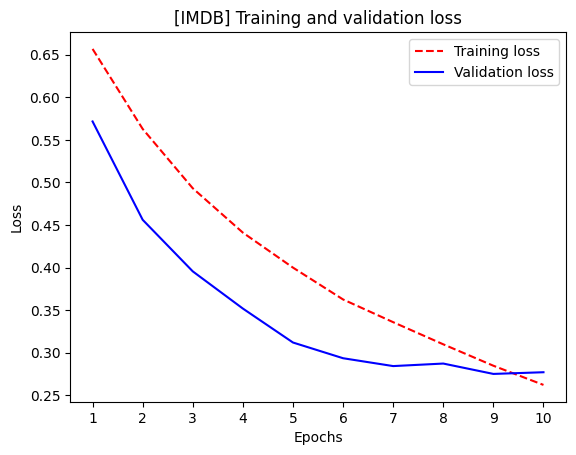

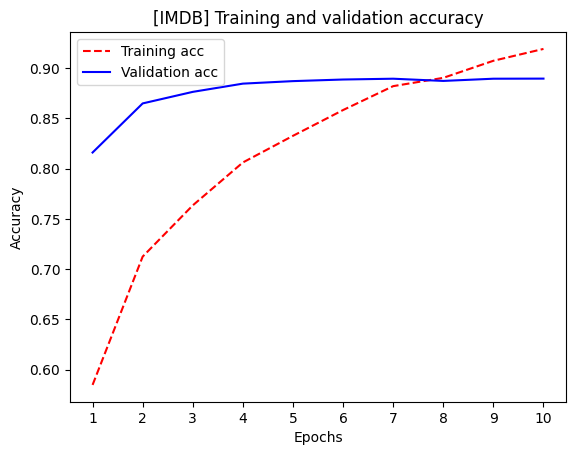

In [118]:
import keras
from keras import layers
from keras import regularizers
from keras import optimizers
import matplotlib.pyplot as plt

import numpy as np

model = keras.Sequential(
    [
        # ORIGINAL
        # layers.Dense(16, activation="relu"),
        # layers.Dense(16, activation="relu"),

        # TRIED, WORKS OKAY
        # layers.Dense(8, kernel_regularizer=regularizers.l2(0.002), activation="relu"),
        # layers.Dense(8, kernel_regularizer=regularizers.l2(0.002), activation="relu"),

        # FINAL CHOICE
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(8, activation="relu"),
        layers.Dropout(0.5),

        layers.Dense(1, activation="sigmoid"),
    ]
)

model.compile(
    # optimizer="adam",
    optimizer="rmsprop", # works better in this case
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

def multi_hot_encode(sequences, num_classes):
    results = np.zeros((len(sequences), num_classes))
    for i, sequence in enumerate(sequences):
        results[i][sequence] = 1.0
    return results

x_train = multi_hot_encode(train_data, num_classes=10000)
x_test = multi_hot_encode(test_data, num_classes=10000)
y_train = train_labels.astype("float32")
y_test = test_labels.astype("float32")

x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=10,
    batch_size=512,
    validation_data=(x_val, y_val),
)

history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, "r--", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("[IMDB] Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("[IMDB] Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
results = model.evaluate(x_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 548us/step - accuracy: 0.8834 - loss: 0.2914
